# Modelando a Nebulosa do Caranguejo


## Importando pacotes para cálculo

In [ ]:
"""
Neste Bloco instalamos na máquina virtual o pacote que será utilizado para realizar a modelagem da fonte.

"""
!pip install naima #rode apenas uma vez

In [ ]:
# ==================================
# IMPORTANDO PACOTES
# ==================================


import astropy.units as u #--UNIDADES FISICA--#
import numpy as np #--CÁLCULO NUMÉRICO--#
from astropy.constants import c #--CONSTANTE FISICA--#
from astropy.io import ascii #--TABELAS--#
from matplotlib import pyplot as plt #--PLOT--#
import naima #--MODELO NAO_TERMICO--#
import pandas as pd #--TABELAS--#
from naima.models import (
    ExponentialCutoffBrokenPowerLaw,
    InverseCompton,
    Synchrotron,
    Bremsstrahlung
)

## **Modelando com o NAIMA**

In [ ]:
# ============================
# DISTRIBUICAO DE PARTICULAS
# ============================

ECBPL = ExponentialCutoffBrokenPowerLaw(
    amplitude=3.699e36 / u.eV,
    e_0=1 * u.TeV,
    e_break=0.265 * u.TeV,
    alpha_1=1.5,
    alpha_2=3.233,
    e_cutoff=1863 * u.TeV,
    beta=2.0,
)


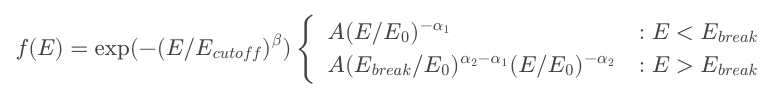

In [ ]:
# ================================
# SINCROTRON
# ================================

SYN = Synchrotron(ECBPL, B = 125 * u.uG, Eemax=50 * u.PeV, Eemin=0.1 * u.GeV) #--Calculo modelo sincrotron--#

# ---------------------------------
# Densidade Espectral de Fótons da emissão síncrotron assumindo R=2.1 pc
# ---------------------------------

Rpwn = 2.1 * u.pc #--Raio Assumindo--#

Esy = np.logspace(-7, 9, 100) * u.eV #--Array de Energia dos fótons síncrotron--#

Lsy = SYN.flux(Esy, distance=0 * u.cm)  #--Luminosidade Espectral (distancia = 0)--#

phn_sy = Lsy / (4 * np.pi * Rpwn**2 * c) * 2.24 #--densidade espectral--#



In [ ]:
# ====================================
# COMPTON INVERSO
# ====================================

IC = InverseCompton(
    ECBPL,
    seed_photon_fields=[
        "CMB",
        ["FIR", 70 * u.K, 0.5 * u.eV / u.cm**3],
        ["NIR", 5000 * u.K, 1 * u.eV / u.cm**3],
        ["SSC", Esy, phn_sy],
    ],
    Eemax=50 * u.PeV,
    Eemin=0.1 * u.GeV,
)

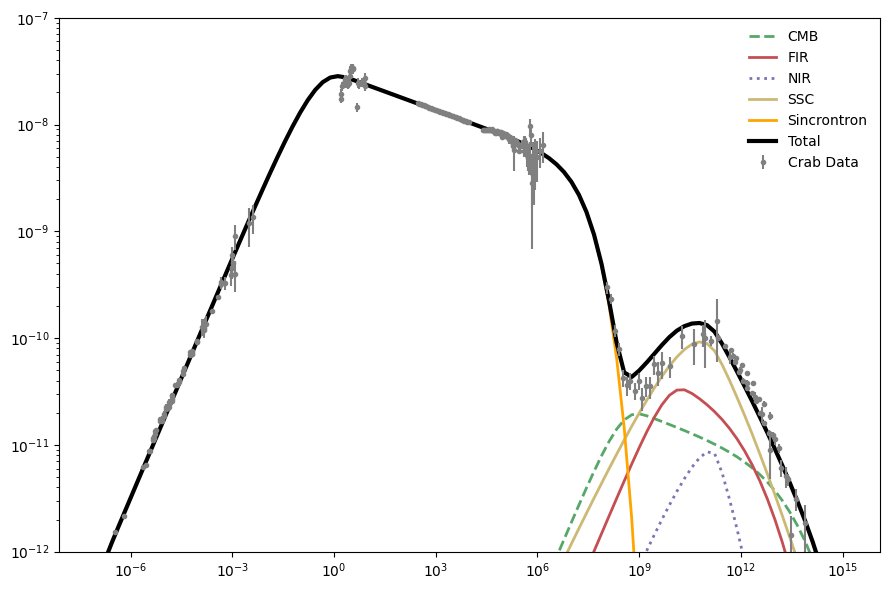

In [ ]:
# ==============================
# DISTANCIA
# ==============================

d = 2 * u.kpc

# ===============================
# ARRAY DE ENERGIA DOS ELETRONS
# ===============================

energy = np.logspace(-7, 15, 100) * u.eV

# ===============================
# CALCULO DAS EMISSOES
# ===============================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

# --------------------------------
# compton inverso
# --------------------------------

for i, seed, ls in zip(range(4), ["CMB", "FIR", "NIR", "SSC"], ["--", "-", ":", "-"]):
    ax.loglog(
        energy,
        IC.sed(energy, d, seed=seed),
        lw=2,
        c=naima.plot.color_cycle[i + 1],
        label=seed,
        ls=ls,
    )

# -------------------------------
# sincrotron
# -------------------------------
ax.loglog(
          energy,
          SYN.sed(energy,d),
          lw = 2,
          c = "orange",
          label = "Sincrontron",
          ls = "-",
)



# --------------------------------
# total
# --------------------------------


ax.loglog(
    energy,
    IC.sed(energy, d) + SYN.sed(energy,d),
    lw=3,
    c="k",
    label="Total",
)


# ================================
# PLOT DADOS
# ================================

data = ascii.read("CrabNebula_spectrum.ecsv")


ax.errorbar(
    data["energy"].to(u.eV).value,
    data["flux"].to(u.erg * u.cm**-2 * u.s**-1).value,
    yerr=data["flux_error"].to(u.erg * u.cm**-2 * u.s**-1).value,
    marker=".",
    ls="none",
    color="grey",
    label="Crab Data",
)



ax.set_ylim(1e-12, 1e-7)
ax.legend(loc="upper right", frameon=False)
figure.tight_layout()
plt.show()

## **Modelando Fontes "Sintéticas"**

### Fonte Leptonica

In [ ]:
# ==========================
# IMPORTANDO DADOS
# ==========================



path_fonte_1 = "fonte_leptonica.csv"

fonte_1_data = pd.read_csv(path_fonte_1)

energy_data = fonte_1_data['energy_eV']

sed_data = fonte_1_data['sed_erg_cm2_s']

sed_err = fonte_1_data['sed_err']

Text(0, 0.5, 'Fluxo [erg cm$^{-2}$ s$^{-1}$]')

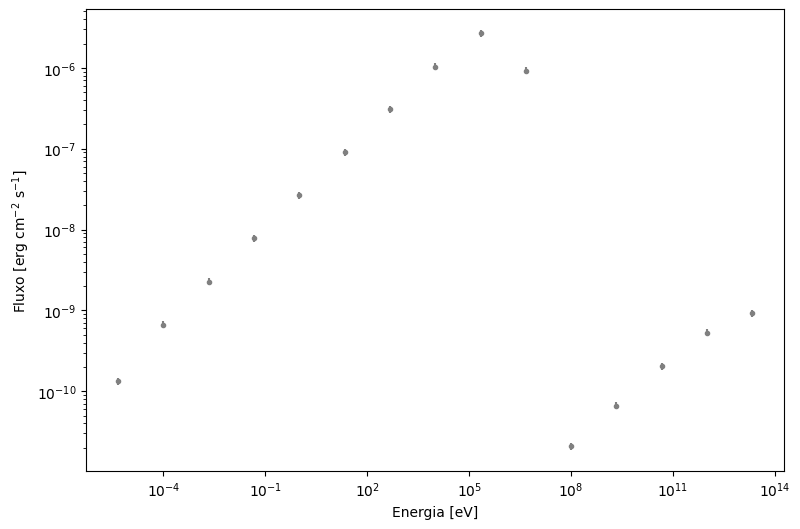

In [ ]:
# ===========================
# VISUALIZANDO DADOS
# ===========================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

ax.errorbar(
    energy_data,# Dados de Energia (energy_data),
    sed_data,# Dados de Fluxo (sed_data),
    sed_err,# Erro de Fluxo (sed_err),
    marker=".",
    ls="none",
    color="grey",
)

ax.set_xscale('log')

ax.set_yscale('log')

ax.set_xlabel('Energia [eV]')
ax.set_ylabel('Fluxo [erg cm$^{-2}$ s$^{-1}$]')

In [ ]:
# =============================
# DISTRIBUICAO DE PARTICULAS
# =============================

from naima.models import PowerLaw


PL = PowerLaw( amplitude = 1E36/u.eV, #float: 1e36 / u.eV
              e_0 = 1* u.TeV,
               alpha = 2.2 #float 2.2,

)



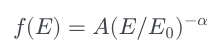

In [ ]:
# =====================
# ARRAY DE ENERGIA
# =====================

E = np.logspace(-6, 14, 200) * u.eV   # 1e-6 eV até 1e14 eV

distance = 2.0 * u.kpc




# ====================
# SINCROTRON
# ====================



SYN = Synchrotron(
    PL,#Distribuicao (PL),
    B = 1E-4*u.G#Campo magnetico B = 1E-4 * u.G,
    )


# =====================
# COMPTON INVERSO
# =====================



IC = InverseCompton(
    PL,#Distribuicao (PL),
    seed_photon_fields =  [
        "CMB",
        "FIR",
        "NIR"]#seed_photon_fields=["CMB","FIR","NIR"]
)


(1e-12, 1e-05)

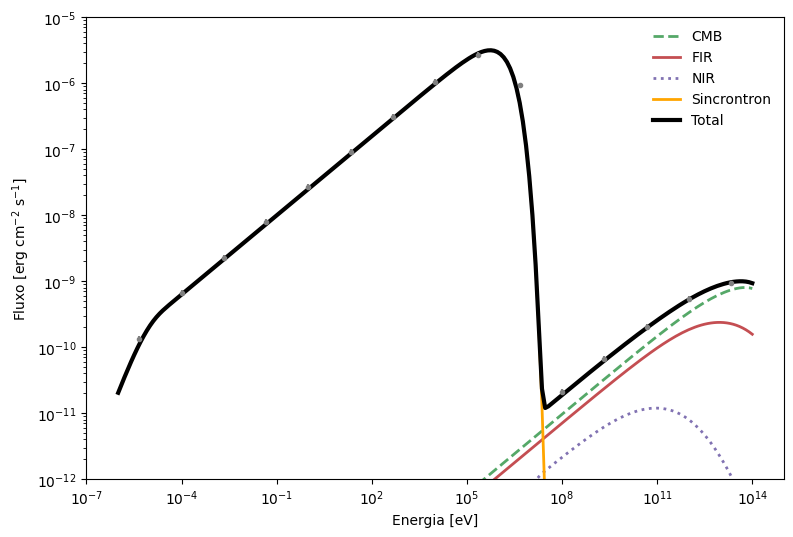

In [ ]:

# ===============================
# CALCULO DAS EMISSOES
# ===============================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

d_fonte_1 = 2 *u.kpc

# --------------------------------
# compton inverso
# --------------------------------

for i, seed, ls in zip(range(3), ["CMB", "FIR", "NIR"], ["--", "-", ":"]): # Removed 'SSC'
    ax.loglog(
        E,
        IC.sed(E, d_fonte_1, seed=seed),#SED: IC.sed(E, d_fonte_1, seed=seed),
        lw=2,
        c=naima.plot.color_cycle[i + 1],
        label=seed,
        ls=ls,
    )

# -------------------------------
# sincrotron
# -------------------------------
ax.loglog(
          E,
          SYN.sed(E,d_fonte_1),#SED: SYN.sed(E,d_fonte_1),
          lw = 2,
          c = "orange",
          label = "Sincrontron",
          ls = "-",
)



# --------------------------------
# total
# --------------------------------


ax.loglog(
    E,
   IC.sed(E, d_fonte_1) + SYN.sed(E,d_fonte_1) , #SED: IC.sed(E, d_fonte_1) + SYN.sed(E,d_fonte_1),
    lw=3,
    c="k",
    label="Total",
)

# ----------------------------------
# dados
# ----------------------------------

ax.errorbar(
    energy_data,# Dados de Energia (energy_data),
    sed_data,# Dados de Fluxo (sed_data),
    sed_err,# Erro de Fluxo (sed_err),
    marker=".",
    ls="none",
    color="grey",
)


ax.set_xlabel('Energia [eV]')
ax.set_ylabel('Fluxo [erg cm$^{-2}$ s$^{-1}$]')
ax.legend(loc="upper right", frameon=False)

plt.ylim(1e-12,1e-5)

### Fonte Mista

In [ ]:
# ==========================
# IMPORTANDO DADOS
# ==========================


path_fonte_2 = 'fonte_mista.csv'
fonte_2_data = pd.read_csv (path_fonte_2)

energy_data_2 = fonte_2_data['energy_eV']

sed_data_2 = fonte_2_data['sed_erg_cm2_s']

sed_err_2 = fonte_2_data['sed_err']


In [ ]:
# ===========================
# VISUALIZANDO DADOS
# ===========================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

ax.errorbar(
    energy_data_2,# Dados de Energia (energy_data),
    sed_data_2,# Dados de Fluxo (sed_data),
    sed_err_2,# Erro de Fluxo (sed_err),
    marker=".",
    ls="none",
    color="grey",
)

ax.set_xscale('log')

ax.set_yscale('log')

In [ ]:
# =============================
# DISTRIBUICAO DE PARTICULAS
# =============================



# -------------------
# ELETRONS
# -------------------

PL = PowerLaw( amplitude = 5E35/u.eV, #float: 1e36 / u.eV
              e_0 = 1* u.TeV,
               alpha = 2.3 #float 2.3,

)

# -------------------
# PROTONS
# -------------------

PL_pp = PowerLaw( amplitude=2e36 / u.eV,
    e_0=1 * u.TeV,
    alpha=2.0 )

In [ ]:
# =====================
# ARRAY DE ENERGIA
# =====================

E = np.logspace(-6, 14, 200) * u.eV   # 1e-6 eV até 1e14 eV

distance = 2.0 * u.kpc




# ====================
# SINCROTRON
# ====================



SYN = Synchrotron(
    PL,#Distribuicao (PL),
    B = 5E-5*u.G#Campo magnetico B = 1E-4 * u.G,
    )


# =====================
# COMPTON INVERSO
# =====================



IC = InverseCompton(
    PL,#Distribuicao (PL),
    seed_photon_fields =  [
        "CMB",
        "FIR",
        "NIR"]#seed_photon_fields=["CMB","FIR","NIR"]
)


# =====================
# PION DECAY
# =====================

from naima.models import PionDecay

PP = PionDecay(
    PL_pp,
    nh = 100 /u.cm**3
)

(1e-12, 1e-05)

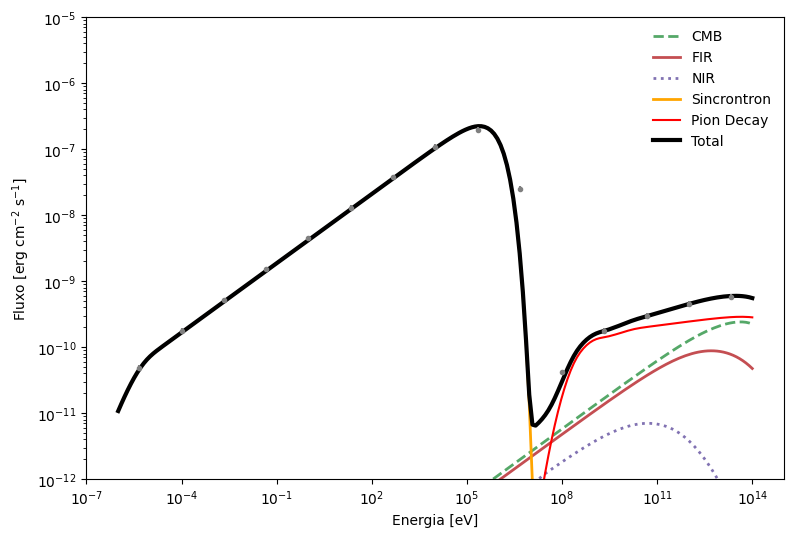

In [ ]:

# ===============================
# CALCULO DAS EMISSOES
# ===============================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

d_fonte_2 = 2 *u.kpc

# --------------------------------
# compton inverso
# --------------------------------

for i, seed, ls in zip(range(3), ["CMB", "FIR", "NIR"], ["--", "-", ":"]): # Removed 'SSC'
    ax.loglog(
        E,
        IC.sed(E, d_fonte_2, seed=seed),#SED: IC.sed(E, d_fonte_1, seed=seed),
        lw=2,
        c=naima.plot.color_cycle[i + 1],
        label=seed,
        ls=ls,
    )

# -------------------------------
# sincrotron
# -------------------------------
ax.loglog(
          E,
          SYN.sed(E,d_fonte_2),#SED: SYN.sed(E,d_fonte_1),
          lw = 2,
          c = "orange",
          label = "Sincrontron",
          ls = "-",
)

# --------------------------------
# PP
# --------------------------------

ax.loglog(
    E,
    PP.sed(E,d_fonte_2),#SED
    c = "red",
    label = "Pion Decay",
    ls = "-"
)

# --------------------------------
# total
# --------------------------------


ax.loglog(
    E,
   IC.sed(E, d_fonte_2) + SYN.sed(E,d_fonte_2) + PP.sed(E,d_fonte_2) ,
    lw=3,
    c="k",
    label="Total",
)

# ----------------------------------
# dados
# ----------------------------------

ax.errorbar(
    energy_data_2,# Dados de Energia (energy_data),
    sed_data_2,# Dados de Fluxo (sed_data),
    sed_err_2,# Erro de Fluxo (sed_err),
    marker=".",
    ls="none",
    color="grey",
)


ax.set_xlabel('Energia [eV]')
ax.set_ylabel('Fluxo [erg cm$^{-2}$ s$^{-1}$]')
ax.legend(loc="upper right", frameon=False)

plt.ylim(1e-12,1e-5)